In [7]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

#### Exercise 4 - Comet Orbit.

Comets usually move in highly elongated elliptical trajectories. According to Kepler's third law, comets spend most of their time far from the Sun, where their orbital speed is lower, and when they approach, they reach very high speeds.

This is therefore a type of physical system where adaptive step methods are very useful. When the comet moves slowly, a large step can be used, while the step must be reduced when approaching the Sun.

1. Show that the equations describing the planet's position in two-dimensional Cartesian coordinates (the comet's motion can always be described in a plane) are:

    $$\frac{\text{d}^2x}{\text{d}t^2}=-GM \frac{x}{r^3},\quad \frac{\text{d}^2y}{\text{d}t^2}=-GM \frac{y}{r^3},$$

    where $r=\sqrt{x^2+y^2}$, $M=1.989 \times 10^{30}$ Kg is the mass of the Sun, and $G=6.6743\times 10^{−11}$ m$^3$/s$^2$/Kg$^2$ is the gravitational constant.

2. Write a program that solves the equations using a fixed-step Runge-Kutta method with initial conditions $x(t=0)=4 \times 10^{9}$ km, $y(t=0)=0$, $v_x=0$, $v_y=500$ m/s. Plot the trajectory in the $xy$ plane. Choose a value of $h$ that allows you to obtain at least two periodic orbits (increasing the error may cause the trajectory to stop being periodic). Check the simulation time.

3. Adapt the program from the previous section to incorporate adaptive step size with a tolerance given by $\delta=1$ km/year in the planet's position. Replot the planet's trajectory. Compare the precision, simulation time, and step size with the result from section 2.


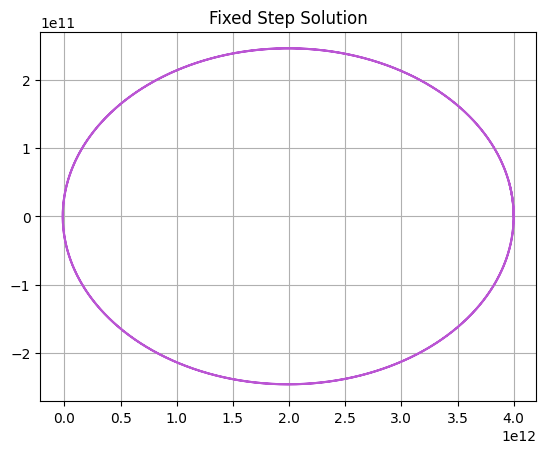

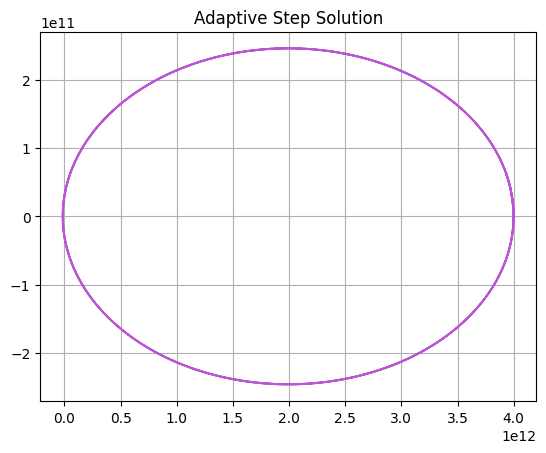

In [15]:
def F(r):
    x = r[0]
    y = r[1]
    vx = r[2]
    vy = r[3]

    M = 1.989e30
    G = 6.6743e-11

    rmod = np.sqrt(x**2 + y**2)

    fx = vx
    fy = vy
    fvx = -G * M * x / (rmod**3)
    fvy = -G * M * y / (rmod**3)

    return np.array([fx, fy, fvx, fvy], float)


r = np.array([4e12, 0, 0, 500], float)
tmax = 3.2e9
h = 1e4

xp = [r[0]]
yp = [r[1]]

t = 0.0
while t < tmax:
    k1 = h * F(r)
    k2 = h * F(r + k1 / 2)
    k3 = h * F(r + k2 / 2)
    k4 = h * F(r + k3)

    r += (k1 + 2 * k2 + 2 * k3 + k4) / 6

    xp.append(r[0])
    yp.append(r[1])
    t += h

plt.plot(xp, yp, color=mc)
plt.grid()
plt.title("Fixed Step Solution")
plt.show()


h0 = 1e4
delta = 1e3 / (365.25 * 24 * 3600)

r = np.array([4e12, 0, 0, 500], float)
xpp = [4e12]
ypp = [0]

t = 0.0
h = h0

while t < tmax:

    k1 = 2 * h * F(r)
    k2 = 2 * h * F(r + k1 / 2)
    k3 = 2 * h * F(r + k2 / 2)
    k4 = 2 * h * F(r + k3)

    r1 = r + (k1 + 2 * k2 + 2 * k3 + k4) / 6

    k1 = h * F(r)
    k2 = h * F(r + k1 / 2)
    k3 = h * F(r + k2 / 2)
    k4 = h * F(r + k3)

    r2 = r + (k1 + 2 * k2 + 2 * k3 + k4) / 6

    k1 = h * F(r2)
    k2 = h * F(r2 + k1 / 2)
    k3 = h * F(r2 + k2 / 2)
    k4 = h * F(r2 + k3)

    r2 += (k1 + 2 * k2 + 2 * k3 + k4) / 6

    dx = r1[0] - r2[0]
    dy = r1[1] - r2[1]

    rho = 30 * h * delta / np.sqrt(dx**2 + dy**2)

    if rho > 1:
        t += 2 * h
        h *= min(rho**0.25, 2.0)
        r = r2
        xpp.append(r[0])
        ypp.append(r[1])
    else:
        h *= rho**0.25

plt.plot(xpp, ypp, color=mc)
plt.grid()
plt.title("Adaptive Step Solution")
plt.show()
